### Invariant of neural representation

- build multivariate gaussian distribution with covariance matrix
- The covariance matrix is built by rotating the original covariance matrix
- The rotation is done by a design matrix B.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd

# --- helpers (same as before) ---
def rotation_matrix_2d(phi_rad: float) -> np.ndarray:
    c, s = np.cos(phi_rad), np.sin(phi_rad)
    return np.array([[c, -s],
                     [s,  c]])

def rotate_cov_2d(Sigma: np.ndarray, phi_rad: float) -> np.ndarray:
    R = rotation_matrix_2d(phi_rad)
    Srot = R @ Sigma @ R.T
    return 0.5 * (Srot + Srot.T)

def eig_sorted(Sigma: np.ndarray):
    w, V = np.linalg.eigh(Sigma)
    idx = np.argsort(w)[::-1]
    return w[idx], V[:, idx]

def ellipse_xy_from_cov(Sigma: np.ndarray, n_std: float = 2.0, num: int = 400):
    w, V = eig_sorted(Sigma)
    radii = n_std * np.sqrt(np.maximum(w, 0))
    t = np.linspace(0, 2*np.pi, num)
    circle = np.vstack([np.cos(t), np.sin(t)])  # 2 x num
    E = V @ np.diag(radii) @ circle
    return E[0], E[1]

def _plot_eigenvectors(ax, Sigma, color, label_prefix, alpha=0.95):
    """
    Plot BOTH eigenvectors (columns of V) scaled to 1σ (sqrt eigenvalues).
    Solid line = eigvec 1 (largest λ), dashed line = eigvec 2.
    Returns two Line2D proxy artists for the legend.
    """
    w, V = eig_sorted(Sigma)
    styles = ["-", "--"]
    labels = [f"{label_prefix} eigvec1 (λ₁)", f"{label_prefix} eigvec2 (λ₂)"]
    proxies = []
    for i in range(2):
        v = V[:, i] * np.sqrt(w[i])  # length = 1σ along that axis
        ax.plot([0, v[0]], [0, v[1]], styles[i], linewidth=2.2, color=color, alpha=alpha)
        # add a faint opposite direction to hint at axis line (optional)
        ax.plot([0, -v[0]], [0, -v[1]], styles[i], linewidth=1.2, color=color, alpha=0.35)
        # proxy for legend (so we can style the legend line exactly)
        proxies.append(Line2D([0], [0], linestyle=styles[i], color=color, lw=2.2, label=labels[i]))
    return proxies


def instantiate_before_after_X(Sigma, Sigma_rot, seed: int = 0, n_samples: int = 600):
    rng = np.random.default_rng(seed)
    X_before = rng.multivariate_normal([0, 0], Sigma, size=n_samples)
    X_after  = rng.multivariate_normal([0, 0], Sigma_rot, size=n_samples)
    return X_before, X_after

# --- one-figure comparison with BOTH eigenvectors ---
def plot_2D_before_after_distribution(Sigma, Sigma_rot, phi_deg: float, seed: int = 0,
                                       n_samples: int = 600, show_samples: bool = True):
    global X_before, X_after
    X_before, X_after = instantiate_before_after_X(Sigma, Sigma_rot, seed=seed, n_samples=n_samples)

    ex1, ey1 = ellipse_xy_from_cov(Sigma, n_std=2.0)
    ex2, ey2 = ellipse_xy_from_cov(Sigma_rot, n_std=2.0)

    fig, ax = plt.subplots(figsize=(7, 6))

    # scatter samples (optional)
    if show_samples:
        ax.scatter(X_before[:,0], X_before[:,1], s=8, alpha=0.25, color="tab:blue",  label="samples (before)")
        ax.scatter(X_after[:,0],  X_after[:,1],  s=8, alpha=0.25, color="tab:orange", label="samples (after)")

    # 2σ ellipses
    l1, = ax.plot(ex1, ey1, lw=2.2, color="tab:blue",  label="ellipse 2σ (before)")
    l2, = ax.plot(ex2, ey2, lw=2.2, color="tab:orange", label=f"ellipse 2σ (after, φ={phi_deg}°)")

    # BOTH eigenvectors for each covariance
    proxies_b = _plot_eigenvectors(ax, Sigma,     color="tab:blue",  label_prefix="before")
    proxies_a = _plot_eigenvectors(ax, Sigma_rot, color="tab:orange", label_prefix="after")

    # assemble legend
    legend_items = []
    if show_samples:
        legend_items += [Line2D([0],[0], marker='o', linestyle='None', color="tab:blue",  alpha=0.25, label="samples (before)"),
                         Line2D([0],[0], marker='o', linestyle='None', color="tab:orange", alpha=0.25, label="samples (after)")]
    legend_items += [l1, l2] + proxies_b + proxies_a
    ax.legend(handles=legend_items, loc="best")

    ax.set_aspect("equal", adjustable="box")
    ax.set_title("Before vs After rotation — both eigenvectors per covariance")
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
    fig.tight_layout()
    plt.show()




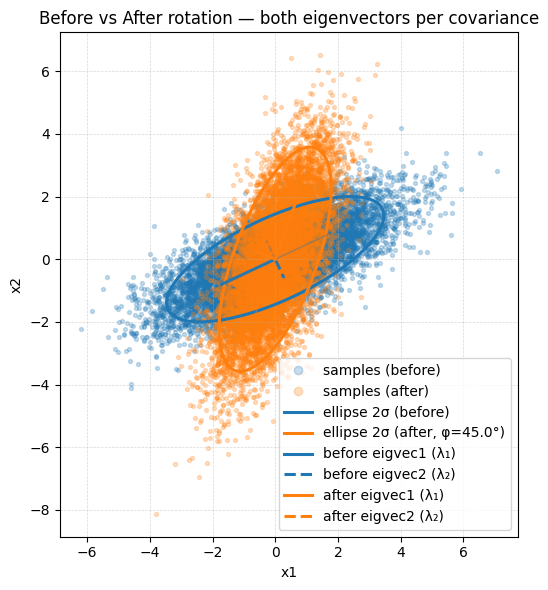

In [2]:
d = 2
m = 2
phi_deg = 45.0
n_samples = 10000
X_seed = 0
# get /sigma
Sigma = np.array([[3.0, 1.2],
                    [1.2, 1.0]])
Sigma_rot = rotate_cov_2d(Sigma, np.deg2rad(phi_deg))

# visualize the before and after covariances with both eigenvectors
plot_2D_before_after_distribution(Sigma, Sigma_rot, phi_deg, n_samples=n_samples, seed=X_seed)

### Apply Leen's complete model to before and after drifted models

In [3]:
from leen_models import LeenCompletePCA
from leen_models import Y_aligned_training_testing, Y_aligned_training_testing_online

In [4]:
def run_experiment(model, data, m, runs = 10, graph = False):
    df_best_corr = pd.DataFrame(data=np.full((runs, m), np.nan), 
                            columns=[f"PC_{i+1}" for i in range(m)],
                            index=[f"run_{i+1}" for i in range(runs)])
    
    for run in range(runs):
        # model = LeenCompletePCA(d, m, eta_w=1e-6, eta_q=1e-2, C=2.0,
        #                   ema_alpha=0.1, symmetrize_q=True, seed=None, settling_steps=10, noise_level=0.01)
        order, similarity = Y_aligned_training_testing_online(model, data, batch_size=1, alignment = "corr")
        # based on the order, sort the similarity to match PC order
        combined_lists = zip(order, similarity)
        # Sort the pairs based on PC_orders
        sorted_combined_lists = sorted(combined_lists)
        # Unzip the sorted pairs
        _, ordered_similarity = zip(*sorted_combined_lists)
        df_best_corr.iloc[run, :] = ordered_similarity
        print(f"run {run+1:2d} | order = {order} | best|corr|= {np.round(similarity,3)}")

    if graph == True:
        # plot the bar graph with error bars of mean and std based on df_best_corr
        means = df_best_corr.mean(axis=0)
        stds = df_best_corr.std(axis=0)
        plt.figure(figsize=(10, 6))
        plt.bar(means.index, means.values, yerr=stds.values, capsize=5)
        # plt.ylim(0, 1.1)
        plt.ylabel('Mean Absolute Correlation')
        plt.title('Mean Absolute Correlation with True PCs Across Runs')
        plt.show()

In [5]:
# runs = 10
model_paras = dict(
    input_dim=2, output_dim=2,
    eta_w=5e-5,          # base
    eta_v=2e-3,          # ~4x eta_w
    C=2.0,
    ema_alpha=0.03,
    symmetrize_V=True,
    seed=None,
    noise_level=0.001,
    settling_steps=10
)


model_paras_after = dict(
    eta_w=1e-3,
    eta_v=3e-3
)

### Single run

In [6]:
# leen_model = LeenCompletePCA(**model_paras)

# run_experiment(leen_model, X_before, m=m, runs=1)

In [7]:
# leen_model.eta_w = 1e-3  # to 2e-3 if the spectral gap is small
# leen_model.eta_q = 3e-3  # keep >= eta_w; up to 5e-3 if columns start to couple

# run_experiment(leen_model, X_after, m=m, runs=1)

### Multiple runs

run  1
X_before
W: [[ 0.90489667 -0.42563131]
 [-0.78621098 -0.61795817]]; V: [[0. 0.]
 [0. 0.]]
step    0 | order = [1 0] | best|corr|= [0.393 0.997]
step 1000 | order = [1 0] | best|corr|= [0.851 0.883]
step 2000 | order = [1 0] | best|corr|= [0.837 0.932]
step 3000 | order = [1 0] | best|corr|= [0.858 0.961]
step 4000 | order = [1 0] | best|corr|= [0.827 0.973]
step 5000 | order = [1 0] | best|corr|= [0.828 0.981]
step 6000 | order = [1 0] | best|corr|= [0.805 0.985]
step 7000 | order = [1 0] | best|corr|= [0.862 0.99 ]
step 8000 | order = [1 0] | best|corr|= [0.925 0.994]
step 9000 | order = [1 0] | best|corr|= [0.898 0.995]


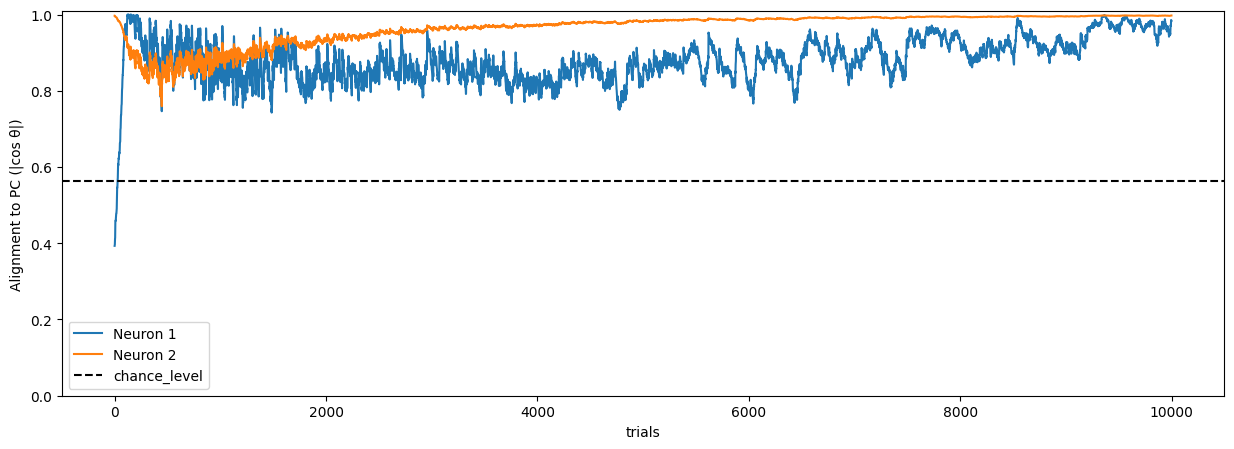

After first phase: model.W = [[ 0.39697393 -0.60169086]
 [-0.83360713 -0.48595374]], model.V: [[0.         0.15318202]
 [0.15318202 0.        ]]
X_after
W: [[ 0.39697393 -0.60169086]
 [-0.83360713 -0.48595374]]; V: [[0.         0.15318202]
 [0.15318202 0.        ]]
step    0 | order = [1 0] | best|corr|= [0.294 0.975]
step 1000 | order = [1 0] | best|corr|= [0.963 0.838]
step 2000 | order = [1 0] | best|corr|= [0.931 0.884]
step 3000 | order = [1 0] | best|corr|= [0.934 0.929]
step 4000 | order = [1 0] | best|corr|= [0.899 0.949]
step 5000 | order = [1 0] | best|corr|= [0.941 0.968]
step 6000 | order = [1 0] | best|corr|= [0.887 0.974]
step 7000 | order = [1 0] | best|corr|= [0.894 0.982]
step 8000 | order = [1 0] | best|corr|= [0.948 0.988]
step 9000 | order = [1 0] | best|corr|= [0.933 0.991]


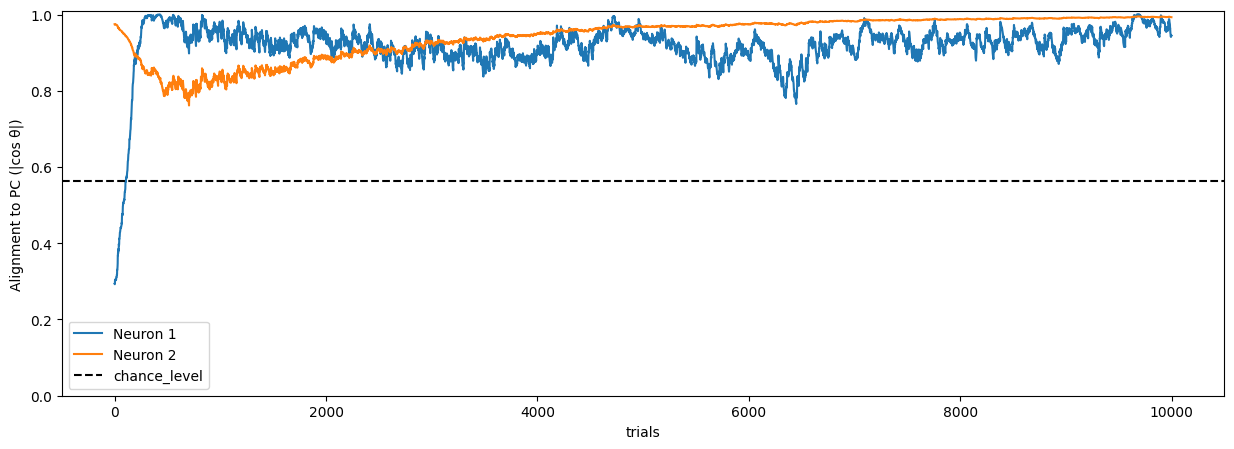

after second phase: model.W = [[ 0.55193063 -0.32319756]
 [-0.49601927 -0.83253832]]; model.V = [[ 0.         -0.20823341]
 [-0.20823341  0.        ]]
run  1 | order = [1 0] | best|corr|= [0.944 0.993]
run  2
X_before
W: [[-0.1405319  -0.99007615]
 [-0.2935392  -0.95594704]]; V: [[0. 0.]
 [0. 0.]]
step    0 | order = [1 0] | best|corr|= [0.469 0.934]
step 1000 | order = [1 0] | best|corr|= [0.392 0.997]
step 2000 | order = [1 0] | best|corr|= [0.427 0.999]
step 3000 | order = [1 0] | best|corr|= [0.525 1.   ]
step 4000 | order = [1 0] | best|corr|= [0.786 0.999]
step 5000 | order = [1 0] | best|corr|= [0.794 1.   ]
step 6000 | order = [1 0] | best|corr|= [0.933 0.999]
step 7000 | order = [1 0] | best|corr|= [0.943 0.999]
step 8000 | order = [1 0] | best|corr|= [0.944 0.999]
step 9000 | order = [1 0] | best|corr|= [0.987 0.999]


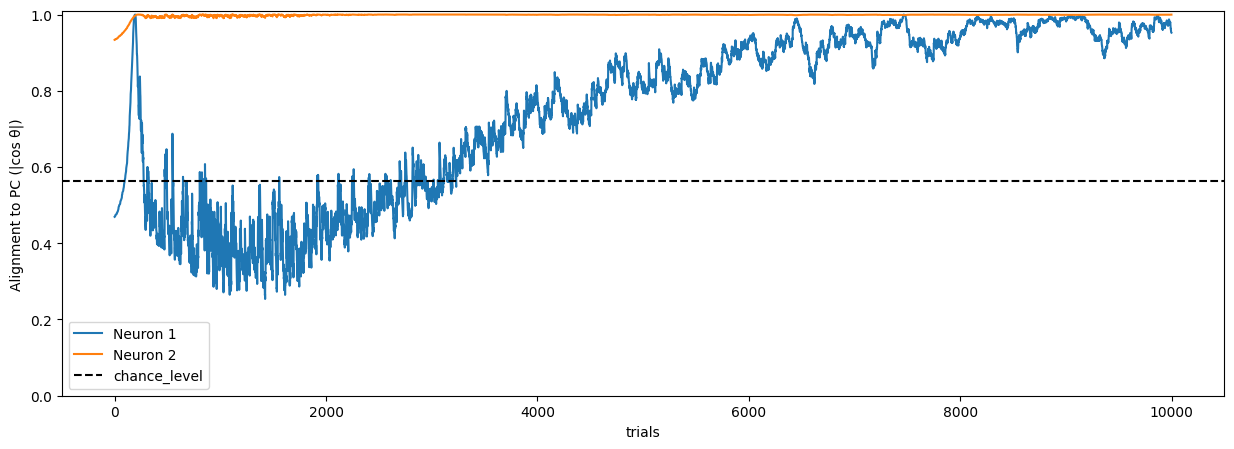

After first phase: model.W = [[ 0.29627901 -0.69290325]
 [-0.81084002 -0.54529226]], model.V: [[ 0.         -0.11622261]
 [-0.11622261  0.        ]]
X_after
W: [[ 0.29627901 -0.69290325]
 [-0.81084002 -0.54529226]]; V: [[ 0.         -0.11622261]
 [-0.11622261  0.        ]]
step    0 | order = [1 0] | best|corr|= [0.403 0.956]
step 1000 | order = [1 0] | best|corr|= [0.947 0.794]
step 2000 | order = [1 0] | best|corr|= [0.895 0.865]
step 3000 | order = [1 0] | best|corr|= [0.888 0.926]
step 4000 | order = [1 0] | best|corr|= [0.839 0.951]
step 5000 | order = [1 0] | best|corr|= [0.884 0.97 ]
step 6000 | order = [1 0] | best|corr|= [0.833 0.977]
step 7000 | order = [1 0] | best|corr|= [0.849 0.985]
step 8000 | order = [1 0] | best|corr|= [0.917 0.99 ]
step 9000 | order = [1 0] | best|corr|= [0.909 0.993]


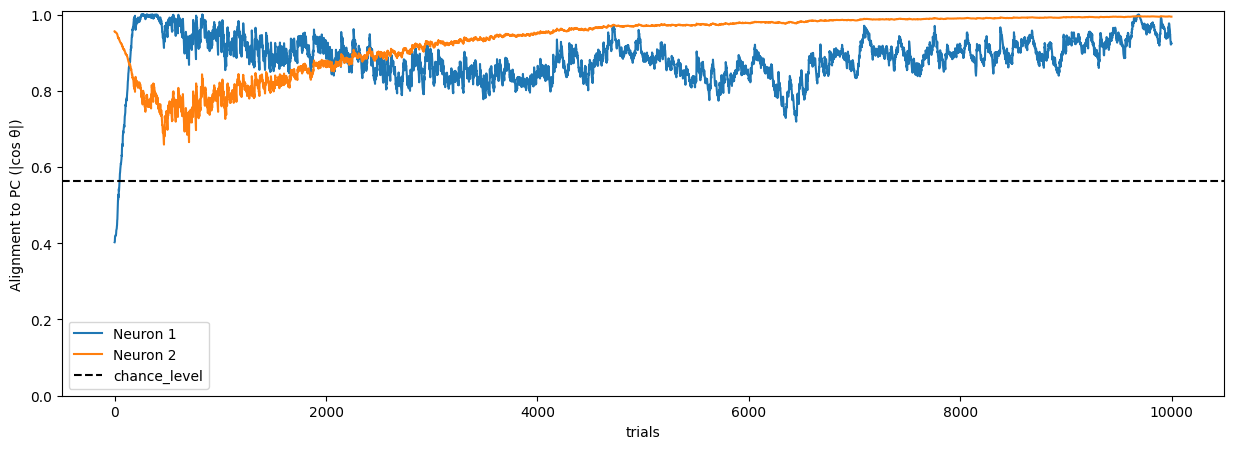

after second phase: model.W = [[ 0.48444227 -0.29386515]
 [-0.47727582 -0.83600683]]; model.V = [[ 0.         -0.20835346]
 [-0.20835346  0.        ]]
run  2 | order = [1 0] | best|corr|= [0.924 0.994]
run  3
X_before
W: [[-0.51505581 -0.85715664]
 [ 0.87783926  0.47895535]]; V: [[0. 0.]
 [0. 0.]]
step    0 | order = [1 0] | best|corr|= [0.227 1.   ]
step 1000 | order = [1 0] | best|corr|= [0.745 0.898]
step 2000 | order = [1 0] | best|corr|= [0.56  0.942]
step 3000 | order = [1 0] | best|corr|= [0.545 0.975]
step 4000 | order = [1 0] | best|corr|= [0.668 0.99 ]
step 5000 | order = [1 0] | best|corr|= [0.632 0.993]
step 6000 | order = [1 0] | best|corr|= [0.795 0.996]
step 7000 | order = [1 0] | best|corr|= [0.808 0.997]
step 8000 | order = [1 0] | best|corr|= [0.829 0.998]
step 9000 | order = [1 0] | best|corr|= [0.908 0.999]


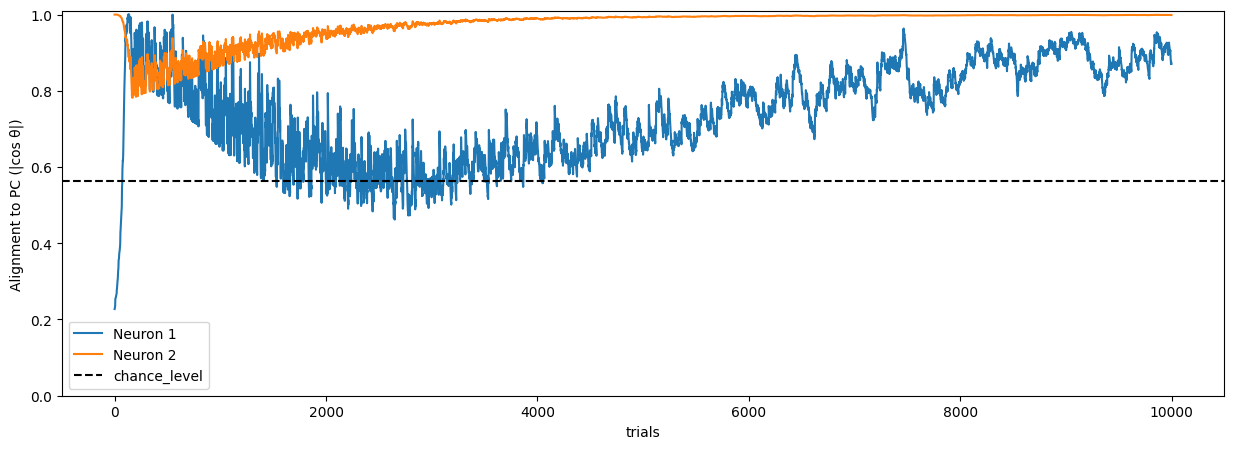

After first phase: model.W = [[ 0.13665915 -0.50221571]
 [ 0.8811003   0.38380587]], model.V: [[0.         0.20293819]
 [0.20293819 0.        ]]
X_after
W: [[ 0.13665915 -0.50221571]
 [ 0.8811003   0.38380587]]; V: [[0.         0.20293819]
 [0.20293819 0.        ]]
step    0 | order = [1 0] | best|corr|= [0.466 0.908]
step 1000 | order = [1 0] | best|corr|= [0.94  0.809]
step 2000 | order = [1 0] | best|corr|= [0.884 0.875]
step 3000 | order = [1 0] | best|corr|= [0.857 0.927]
step 4000 | order = [1 0] | best|corr|= [0.805 0.951]
step 5000 | order = [1 0] | best|corr|= [0.843 0.969]
step 6000 | order = [1 0] | best|corr|= [0.79  0.977]
step 7000 | order = [1 0] | best|corr|= [0.804 0.985]
step 8000 | order = [1 0] | best|corr|= [0.877 0.99 ]
step 9000 | order = [1 0] | best|corr|= [0.872 0.992]


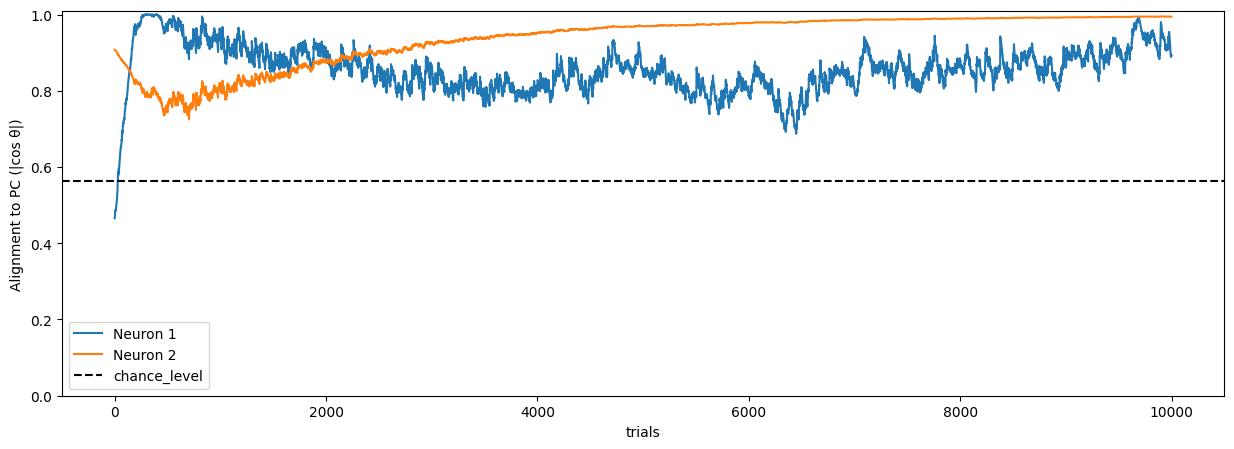

after second phase: model.W = [[ 0.34157736 -0.22823461]
 [ 0.51796164  0.81934891]]; model.V = [[0.         0.18672958]
 [0.18672958 0.        ]]
run  3 | order = [1 0] | best|corr|= [0.891 0.994]
run  4
X_before
W: [[-0.47270482  0.88122083]
 [ 0.07831971  0.99692829]]; V: [[0. 0.]
 [0. 0.]]
step    0 | order = [1 0] | best|corr|= [0.99  0.853]
step 1000 | order = [1 0] | best|corr|= [0.84  0.935]
step 2000 | order = [1 0] | best|corr|= [0.865 0.94 ]
step 3000 | order = [1 0] | best|corr|= [0.897 0.946]
step 4000 | order = [1 0] | best|corr|= [0.992 0.932]
step 5000 | order = [1 0] | best|corr|= [0.996 0.944]
step 6000 | order = [1 0] | best|corr|= [0.999 0.947]
step 7000 | order = [1 0] | best|corr|= [0.999 0.958]
step 8000 | order = [1 0] | best|corr|= [0.999 0.968]
step 9000 | order = [1 0] | best|corr|= [0.994 0.972]


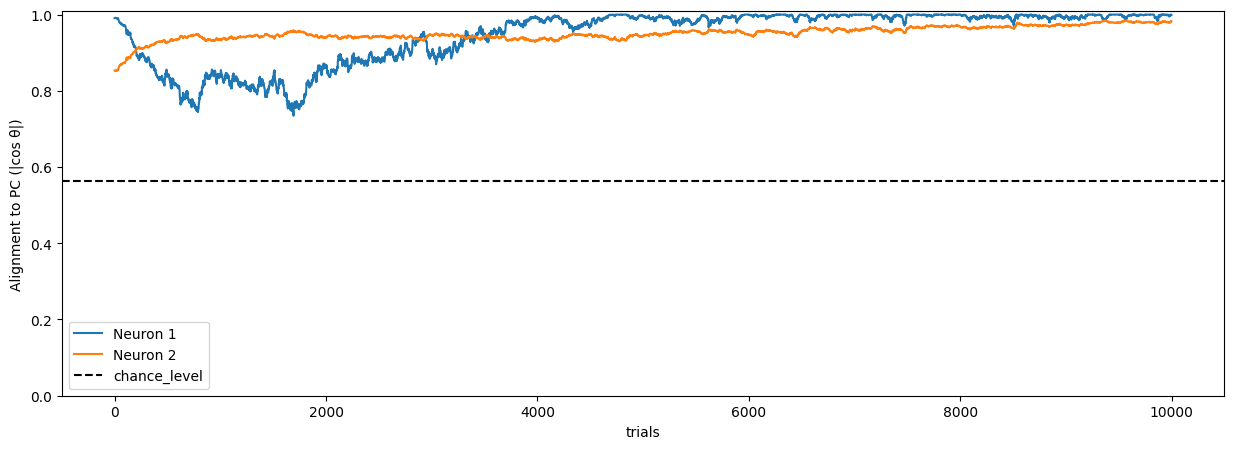

After first phase: model.W = [[-0.55069194  0.81266447]
 [ 0.68828922  0.71229451]], model.V: [[0.         0.14150013]
 [0.14150013 0.        ]]
X_after
W: [[-0.55069194  0.81266447]
 [ 0.68828922  0.71229451]]; V: [[0.         0.14150013]
 [0.14150013 0.        ]]
step    0 | order = [1 0] | best|corr|= [0.341 0.995]
step 1000 | order = [1 0] | best|corr|= [0.941 0.852]
step 2000 | order = [1 0] | best|corr|= [0.896 0.898]
step 3000 | order = [1 0] | best|corr|= [0.915 0.944]
step 4000 | order = [1 0] | best|corr|= [0.879 0.96 ]
step 5000 | order = [1 0] | best|corr|= [0.936 0.976]
step 6000 | order = [1 0] | best|corr|= [0.889 0.98 ]
step 7000 | order = [1 0] | best|corr|= [0.901 0.986]
step 8000 | order = [1 0] | best|corr|= [0.956 0.992]
step 9000 | order = [1 0] | best|corr|= [0.945 0.993]


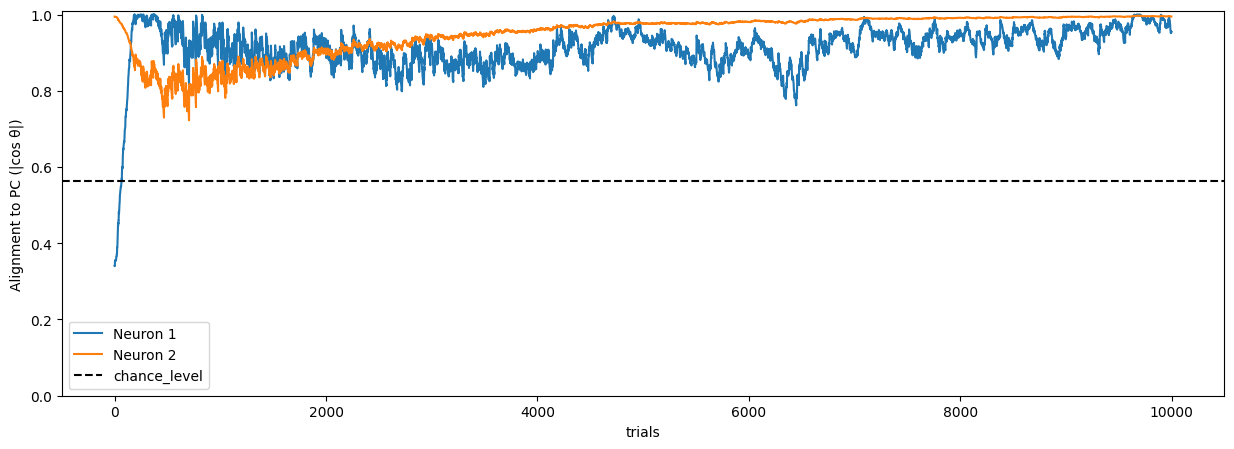

after second phase: model.W = [[-0.65204975  0.3558445 ]
 [ 0.44038815  0.85955391]]; model.V = [[ 0.         -0.20558424]
 [-0.20558424  0.        ]]
run  4 | order = [1 0] | best|corr|= [0.954 0.995]
run  5
X_before
W: [[ 0.86212777  0.50669095]
 [-0.59134172 -0.80642109]]; V: [[0. 0.]
 [0. 0.]]
step    0 | order = [0 1] | best|corr|= [1.    0.186]
step 1000 | order = [0 1] | best|corr|= [0.895 0.765]
step 2000 | order = [0 1] | best|corr|= [0.936 0.526]
step 3000 | order = [0 1] | best|corr|= [0.975 0.476]
step 4000 | order = [0 1] | best|corr|= [0.991 0.575]
step 5000 | order = [0 1] | best|corr|= [0.993 0.54 ]
step 6000 | order = [0 1] | best|corr|= [0.997 0.702]
step 7000 | order = [0 1] | best|corr|= [0.997 0.726]
step 8000 | order = [0 1] | best|corr|= [0.998 0.765]
step 9000 | order = [0 1] | best|corr|= [0.999 0.854]


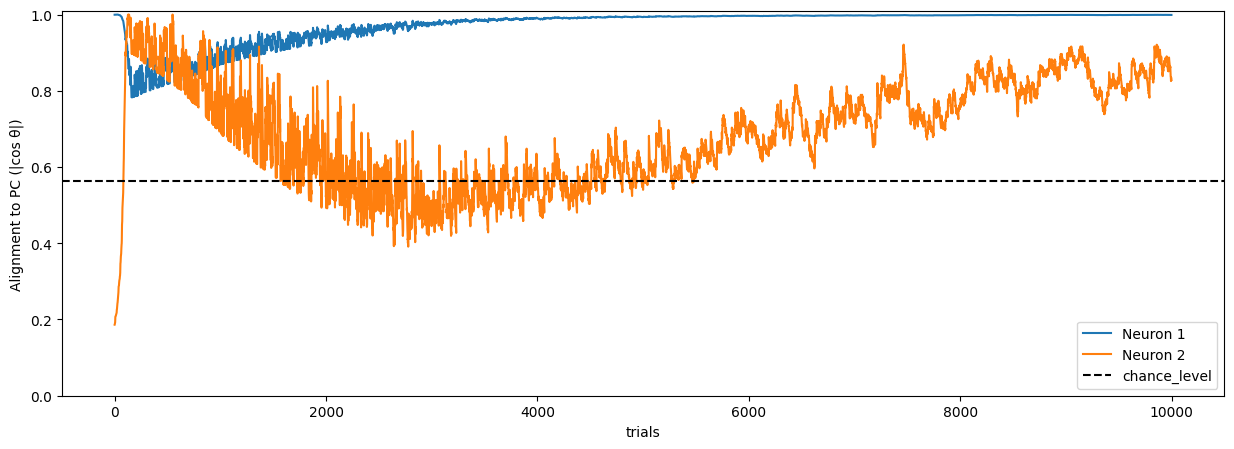

After first phase: model.W = [[ 0.87500066  0.38811772]
 [ 0.10570946 -0.44816807]], model.V: [[0.         0.21426832]
 [0.21426832 0.        ]]
X_after
W: [[ 0.87500066  0.38811772]
 [ 0.10570946 -0.44816807]]; V: [[0.         0.21426832]
 [0.21426832 0.        ]]
step    0 | order = [0 1] | best|corr|= [0.912 0.496]
step 1000 | order = [0 1] | best|corr|= [0.856 0.903]
step 2000 | order = [0 1] | best|corr|= [0.908 0.84 ]
step 3000 | order = [0 1] | best|corr|= [0.944 0.814]
step 4000 | order = [0 1] | best|corr|= [0.962 0.765]
step 5000 | order = [0 1] | best|corr|= [0.975 0.817]
step 6000 | order = [0 1] | best|corr|= [0.982 0.768]
step 7000 | order = [0 1] | best|corr|= [0.988 0.786]
step 8000 | order = [0 1] | best|corr|= [0.991 0.865]
step 9000 | order = [0 1] | best|corr|= [0.994 0.863]


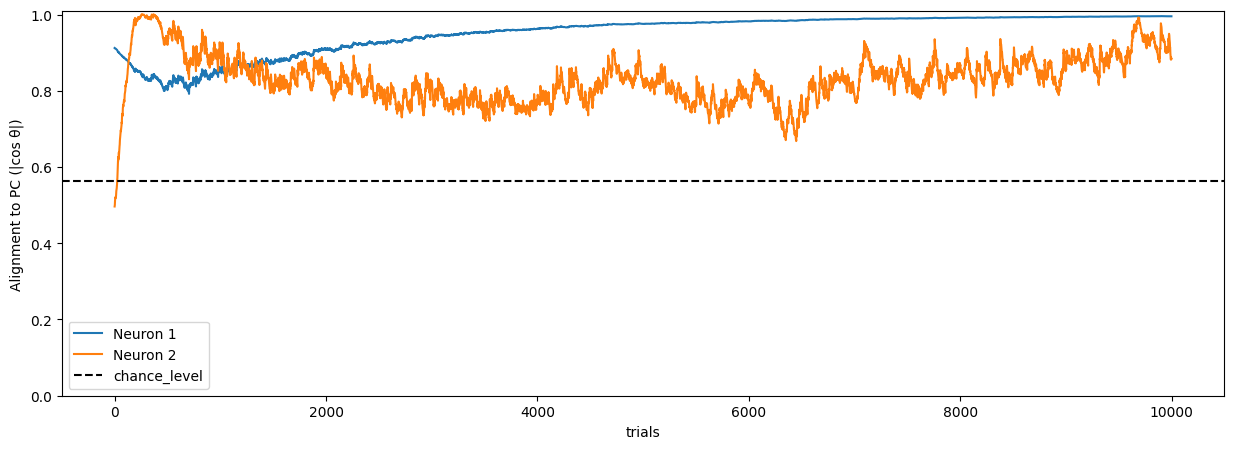

after second phase: model.W = [[ 0.51360586  0.82912668]
 [ 0.29829686 -0.19976427]]; model.V = [[0.         0.16502212]
 [0.16502212 0.        ]]
run  5 | order = [0 1] | best|corr|= [0.995 0.883]
run  6
X_before
W: [[ 0.78960664 -0.61361336]
 [ 0.99437171  0.10594767]]; V: [[0. 0.]
 [0. 0.]]
step    0 | order = [1 0] | best|corr|= [0.572 0.993]
step 1000 | order = [1 0] | best|corr|= [0.719 0.987]
step 2000 | order = [1 0] | best|corr|= [0.767 0.992]
step 3000 | order = [1 0] | best|corr|= [0.865 0.996]
step 4000 | order = [1 0] | best|corr|= [0.842 0.997]
step 5000 | order = [1 0] | best|corr|= [0.878 0.998]
step 6000 | order = [1 0] | best|corr|= [0.848 0.998]
step 7000 | order = [1 0] | best|corr|= [0.906 0.999]
step 8000 | order = [1 0] | best|corr|= [0.968 1.   ]
step 9000 | order = [1 0] | best|corr|= [0.937 0.999]


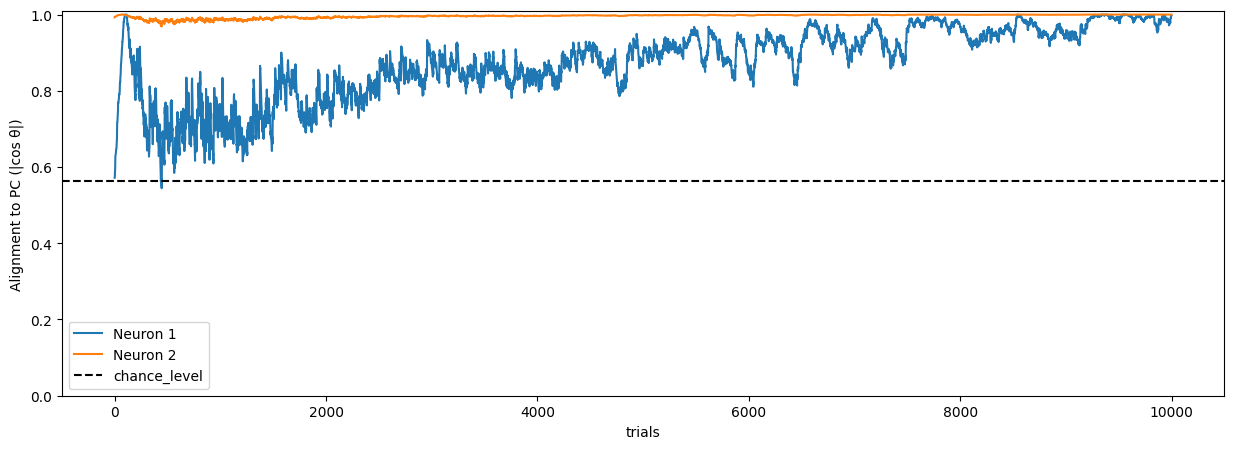

After first phase: model.W = [[ 0.41030789 -0.74612836]
 [ 0.90175986  0.38941923]], model.V: [[ 0.         -0.07319776]
 [-0.07319776  0.        ]]
X_after
W: [[ 0.41030789 -0.74612836]
 [ 0.90175986  0.38941923]]; V: [[ 0.         -0.07319776]
 [-0.07319776  0.        ]]
step    0 | order = [1 0] | best|corr|= [0.316 0.951]
step 1000 | order = [1 0] | best|corr|= [1.    0.519]
step 2000 | order = [1 0] | best|corr|= [0.999 0.607]
step 3000 | order = [1 0] | best|corr|= [1.   0.73]
step 4000 | order = [1 0] | best|corr|= [0.995 0.804]
step 5000 | order = [1 0] | best|corr|= [0.97  0.865]
step 6000 | order = [1 0] | best|corr|= [0.907 0.9  ]
step 7000 | order = [1 0] | best|corr|= [0.889 0.938]
step 8000 | order = [1 0] | best|corr|= [0.925 0.962]
step 9000 | order = [1 0] | best|corr|= [0.898 0.972]


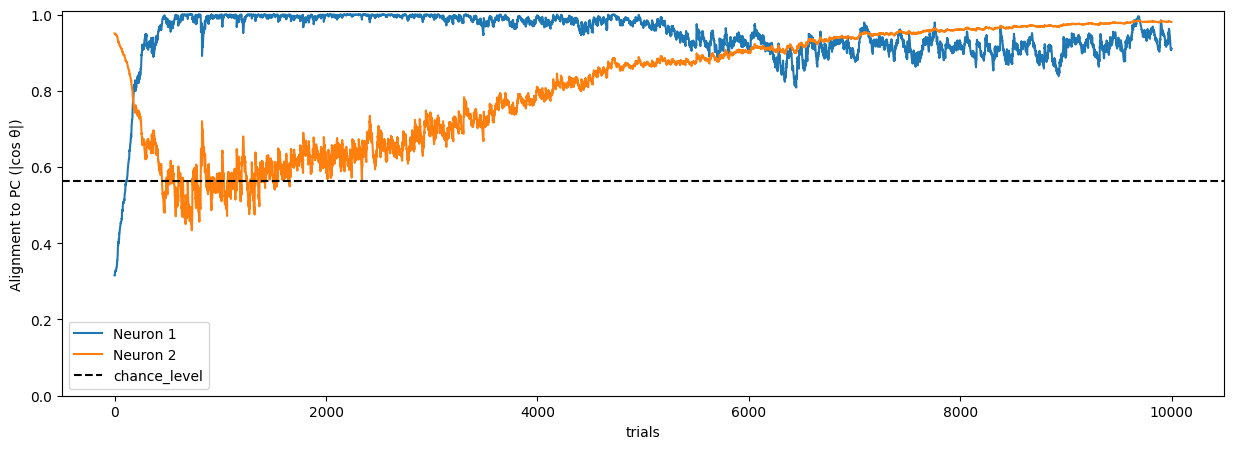

after second phase: model.W = [[ 0.51276441 -0.37557269]
 [ 0.55557184  0.73609476]]; model.V = [[0.         0.33042482]
 [0.33042482 0.        ]]
run  6 | order = [1 0] | best|corr|= [0.91 0.98]
run  7
X_before
W: [[-0.42671565 -0.90438584]
 [ 0.13965376 -0.9902004 ]]; V: [[0. 0.]
 [0. 0.]]
step    0 | order = [0 1] | best|corr|= [0.961 0.747]
step 1000 | order = [0 1] | best|corr|= [1.    0.649]
step 2000 | order = [0 1] | best|corr|= [1.    0.755]
step 3000 | order = [0 1] | best|corr|= [1.    0.766]
step 4000 | order = [0 1] | best|corr|= [0.998 0.95 ]
step 5000 | order = [0 1] | best|corr|= [0.999 0.938]
step 6000 | order = [0 1] | best|corr|= [0.998 0.995]
step 7000 | order = [0 1] | best|corr|= [0.999 0.993]
step 8000 | order = [0 1] | best|corr|= [0.999 0.985]
step 9000 | order = [0 1] | best|corr|= [0.999 1.   ]


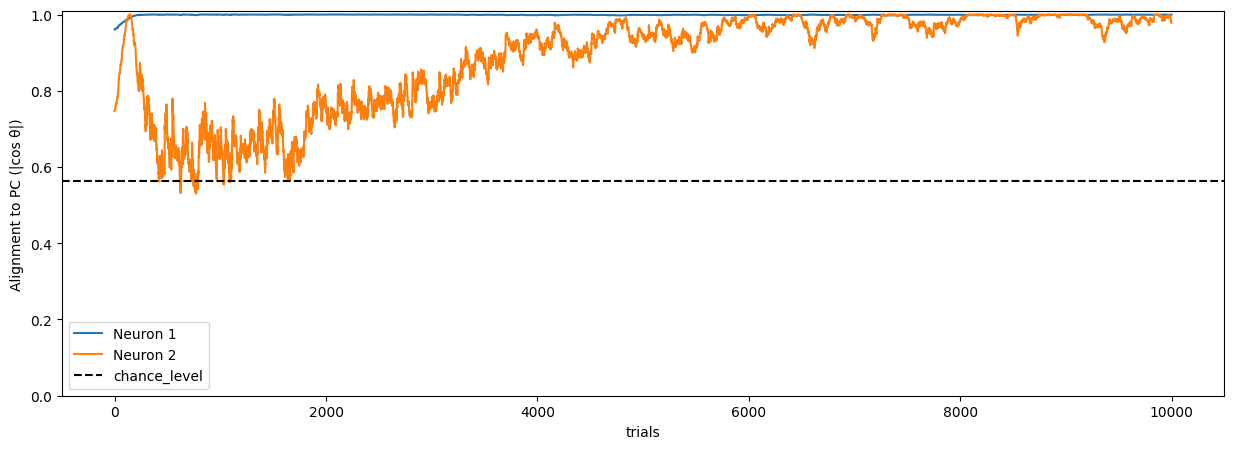

After first phase: model.W = [[-0.83127371 -0.5395537 ]
 [ 0.39178223 -0.83391531]], model.V: [[ 0.         -0.07268388]
 [-0.07268388  0.        ]]
X_after
W: [[-0.83127371 -0.5395537 ]
 [ 0.39178223 -0.83391531]]; V: [[ 0.         -0.07268388]
 [-0.07268388  0.        ]]
step    0 | order = [0 1] | best|corr|= [0.957 0.377]
step 1000 | order = [0 1] | best|corr|= [0.583 0.99 ]
step 2000 | order = [0 1] | best|corr|= [0.701 0.98 ]
step 3000 | order = [0 1] | best|corr|= [0.836 0.975]
step 4000 | order = [0 1] | best|corr|= [0.892 0.928]
step 5000 | order = [0 1] | best|corr|= [0.934 0.916]
step 6000 | order = [0 1] | best|corr|= [0.953 0.856]
step 7000 | order = [0 1] | best|corr|= [0.97  0.858]
step 8000 | order = [0 1] | best|corr|= [0.981 0.915]
step 9000 | order = [0 1] | best|corr|= [0.986 0.901]


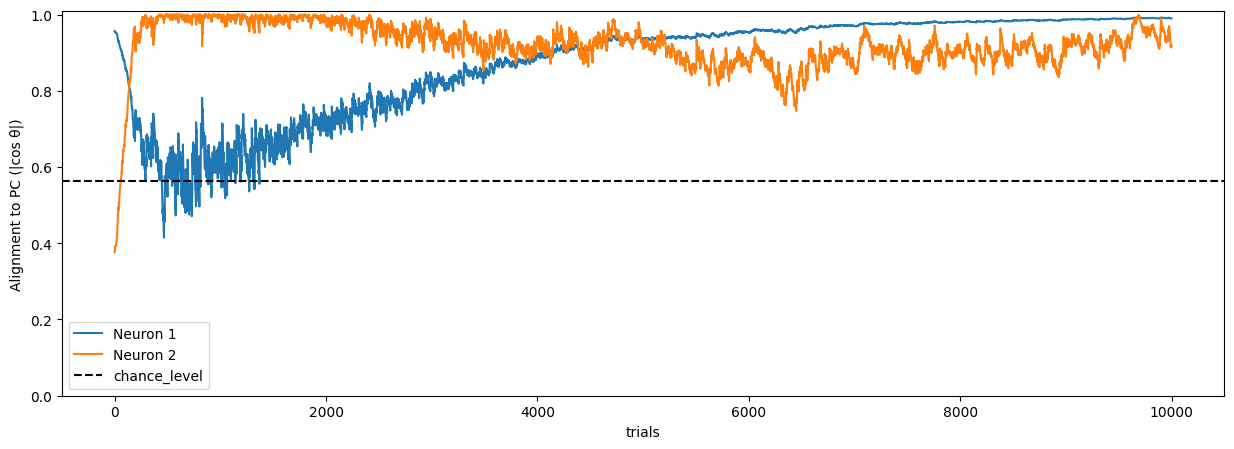

after second phase: model.W = [[-0.49942007 -0.79674508]
 [ 0.52268883 -0.34090853]]; model.V = [[ 0.         -0.26584031]
 [-0.26584031  0.        ]]
run  7 | order = [0 1] | best|corr|= [0.99  0.916]
run  8
X_before
W: [[ 0.65019147 -0.75977039]
 [-0.96065948  0.27772895]]; V: [[0. 0.]
 [0. 0.]]
step    0 | order = [1 0] | best|corr|= [0.792 0.955]
step 1000 | order = [1 0] | best|corr|= [0.721 1.   ]
step 2000 | order = [1 0] | best|corr|= [0.784 0.999]
step 3000 | order = [1 0] | best|corr|= [0.906 0.998]
step 4000 | order = [1 0] | best|corr|= [0.887 0.999]
step 5000 | order = [1 0] | best|corr|= [0.934 0.999]
step 6000 | order = [1 0] | best|corr|= [0.898 0.999]
step 7000 | order = [1 0] | best|corr|= [0.942 0.999]
step 8000 | order = [1 0] | best|corr|= [0.99  0.998]
step 9000 | order = [1 0] | best|corr|= [0.964 0.999]


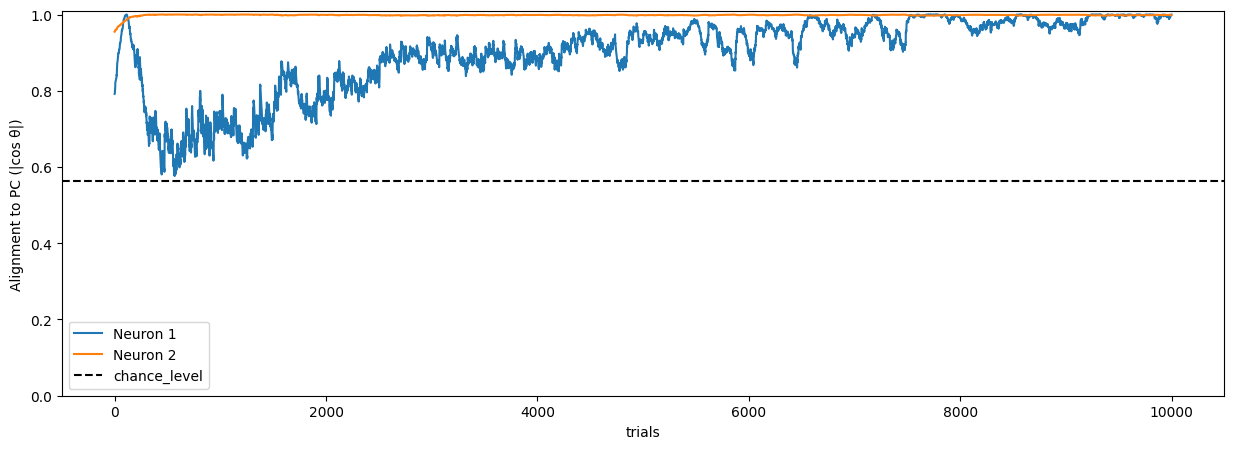

After first phase: model.W = [[ 0.39382613 -0.85479609]
 [-0.95061715 -0.28500867]], model.V: [[ 0.         -0.01491946]
 [-0.01491946  0.        ]]
X_after
W: [[ 0.39382613 -0.85479609]
 [-0.95061715 -0.28500867]]; V: [[ 0.         -0.01491946]
 [-0.01491946  0.        ]]
step    0 | order = [0 1] | best|corr|= [0.943 0.436]
step 1000 | order = [0 1] | best|corr|= [0.441 0.998]
step 2000 | order = [0 1] | best|corr|= [0.621 0.991]
step 3000 | order = [0 1] | best|corr|= [0.699 0.999]
step 4000 | order = [0 1] | best|corr|= [0.806 1.   ]
step 5000 | order = [0 1] | best|corr|= [0.826 0.969]
step 6000 | order = [0 1] | best|corr|= [0.878 0.926]
step 7000 | order = [0 1] | best|corr|= [0.927 0.926]
step 8000 | order = [0 1] | best|corr|= [0.948 0.9  ]
step 9000 | order = [0 1] | best|corr|= [0.967 0.917]


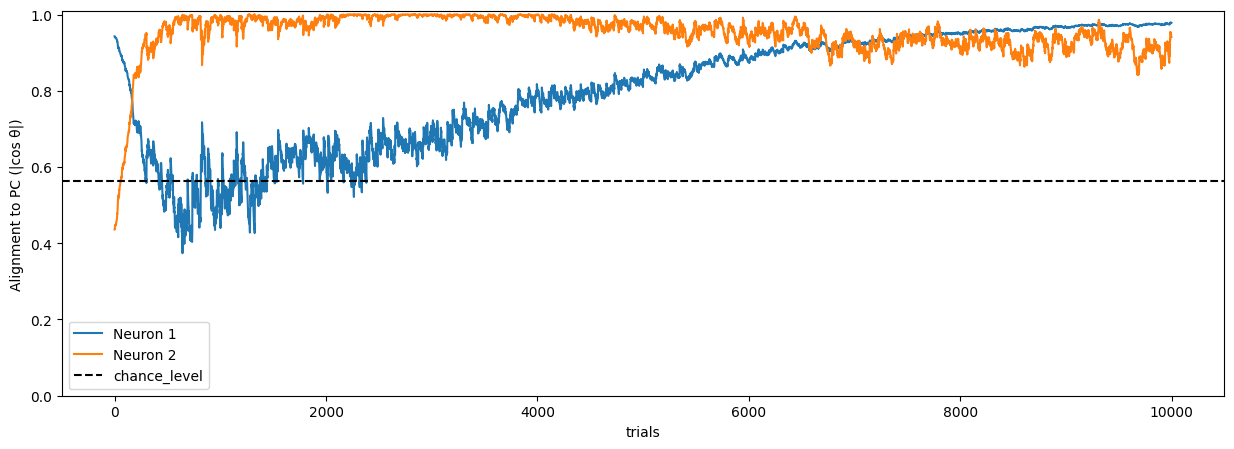

after second phase: model.W = [[-0.0438722  -0.9098838 ]
 [-0.70205752  0.04863065]]; model.V = [[ 0.         -0.33066675]
 [-0.33066675  0.        ]]
run  8 | order = [0 1] | best|corr|= [0.978 0.941]
run  9
X_before
W: [[-0.99066977  0.13628429]
 [-0.12012667  0.99275857]]; V: [[0. 0.]
 [0. 0.]]
step    0 | order = [0 1] | best|corr|= [0.975 0.724]
step 1000 | order = [0 1] | best|corr|= [0.907 0.964]
step 2000 | order = [0 1] | best|corr|= [0.937 0.98 ]
step 3000 | order = [0 1] | best|corr|= [0.946 0.95 ]
step 4000 | order = [0 1] | best|corr|= [0.968 0.989]
step 5000 | order = [0 1] | best|corr|= [0.971 0.963]
step 6000 | order = [0 1] | best|corr|= [0.984 0.999]
step 7000 | order = [0 1] | best|corr|= [0.986 0.993]
step 8000 | order = [0 1] | best|corr|= [0.987 0.976]
step 9000 | order = [0 1] | best|corr|= [0.992 0.998]


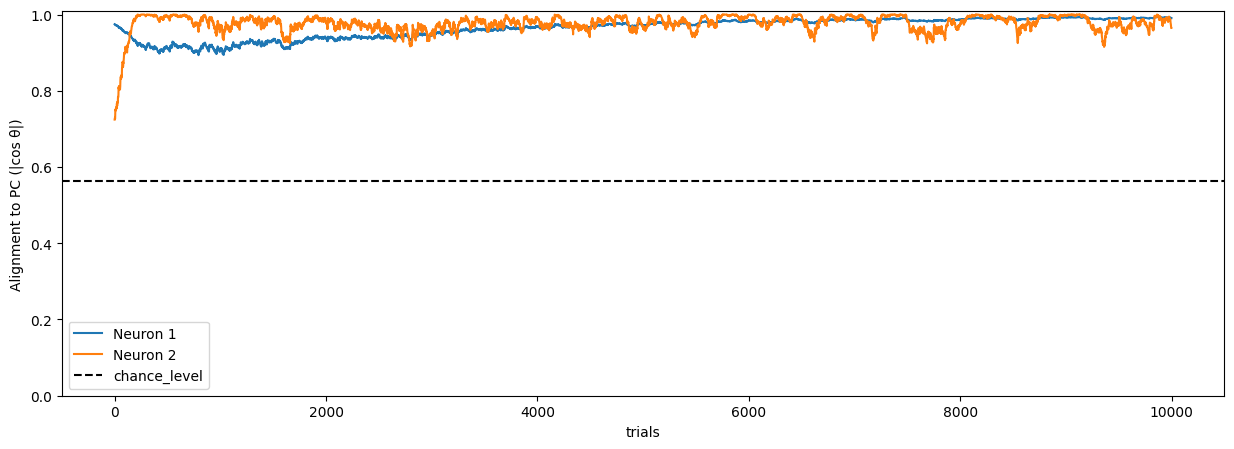

After first phase: model.W = [[-0.94513454 -0.26492205]
 [-0.28196938  0.87896285]], model.V: [[0.        0.2199063]
 [0.2199063 0.       ]]
X_after
W: [[-0.94513454 -0.26492205]
 [-0.28196938  0.87896285]]; V: [[0.        0.2199063]
 [0.2199063 0.       ]]
step    0 | order = [1 0] | best|corr|= [0.619 0.92 ]
step 1000 | order = [1 0] | best|corr|= [0.989 0.617]
step 2000 | order = [1 0] | best|corr|= [0.997 0.779]
step 3000 | order = [1 0] | best|corr|= [0.975 0.84 ]
step 4000 | order = [1 0] | best|corr|= [0.978 0.906]
step 5000 | order = [1 0] | best|corr|= [0.904 0.921]
step 6000 | order = [1 0] | best|corr|= [0.898 0.948]
step 7000 | order = [1 0] | best|corr|= [0.92  0.968]
step 8000 | order = [1 0] | best|corr|= [0.905 0.976]
step 9000 | order = [1 0] | best|corr|= [0.936 0.984]


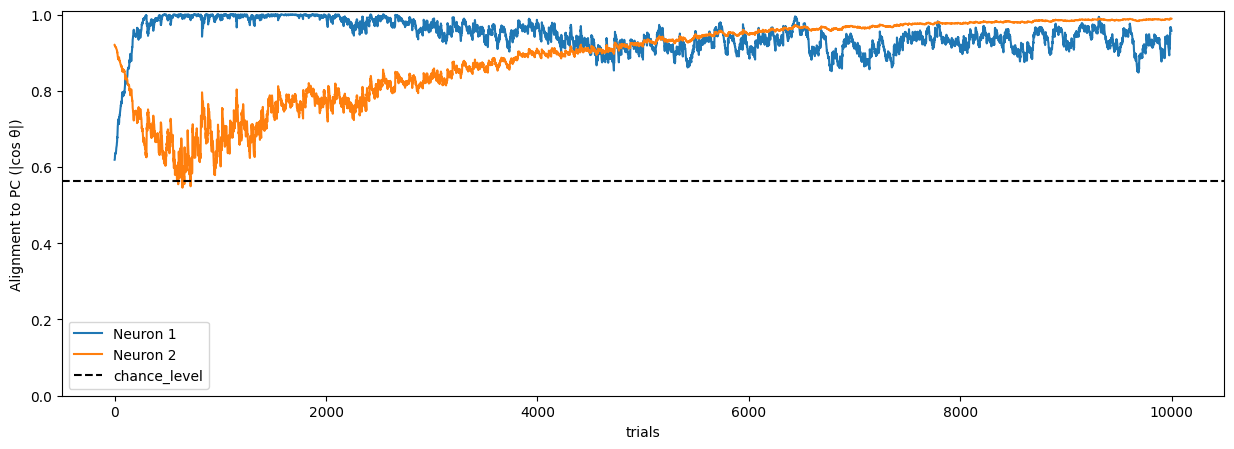

after second phase: model.W = [[-0.73006209  0.10444679]
 [ 0.12714467  0.93420366]]; model.V = [[0.         0.24952716]
 [0.24952716 0.        ]]
run  9 | order = [1 0] | best|corr|= [0.957 0.989]
run 10
X_before
W: [[ 0.3568837  -0.93414883]
 [-0.8205958  -0.57150899]]; V: [[0. 0.]
 [0. 0.]]
step    0 | order = [1 0] | best|corr|= [0.976 0.998]
step 1000 | order = [1 0] | best|corr|= [0.957 1.   ]
step 2000 | order = [1 0] | best|corr|= [0.982 1.   ]
step 3000 | order = [1 0] | best|corr|= [0.949 1.   ]
step 4000 | order = [1 0] | best|corr|= [1. 1.]
step 5000 | order = [1 0] | best|corr|= [0.997 1.   ]
step 6000 | order = [1 0] | best|corr|= [0.991 0.999]
step 7000 | order = [1 0] | best|corr|= [0.998 1.   ]
step 8000 | order = [1 0] | best|corr|= [0.999 1.   ]
step 9000 | order = [1 0] | best|corr|= [0.996 1.   ]


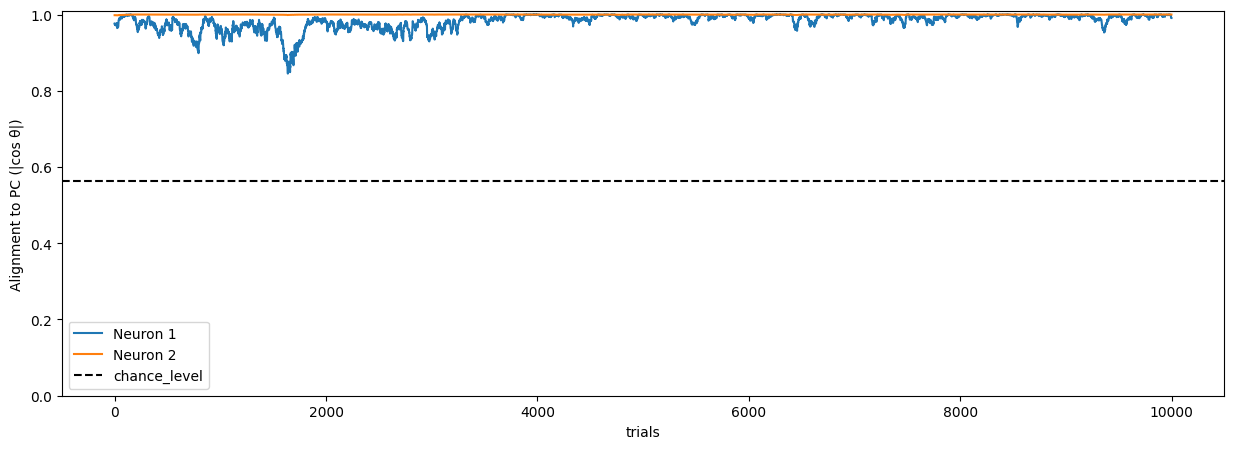

After first phase: model.W = [[ 0.42080513 -0.89889216]
 [-0.8895285  -0.45404187]], model.V: [[ 0.         -0.05298262]
 [-0.05298262  0.        ]]
X_after
W: [[ 0.42080513 -0.89889216]
 [-0.8895285  -0.45404187]]; V: [[ 0.         -0.05298262]
 [-0.05298262  0.        ]]
step    0 | order = [1 0] | best|corr|= [0.36 0.94]
step 1000 | order = [1 0] | best|corr|= [0.993 0.252]
step 2000 | order = [1 0] | best|corr|= [0.965 0.377]
step 3000 | order = [1 0] | best|corr|= [0.949 0.476]
step 4000 | order = [1 0] | best|corr|= [0.94  0.546]
step 5000 | order = [1 0] | best|corr|= [0.994 0.558]
step 6000 | order = [1 0] | best|corr|= [0.994 0.612]
step 7000 | order = [1 0] | best|corr|= [0.977 0.75 ]
step 8000 | order = [1 0] | best|corr|= [0.961 0.852]
step 9000 | order = [1 0] | best|corr|= [0.902 0.905]


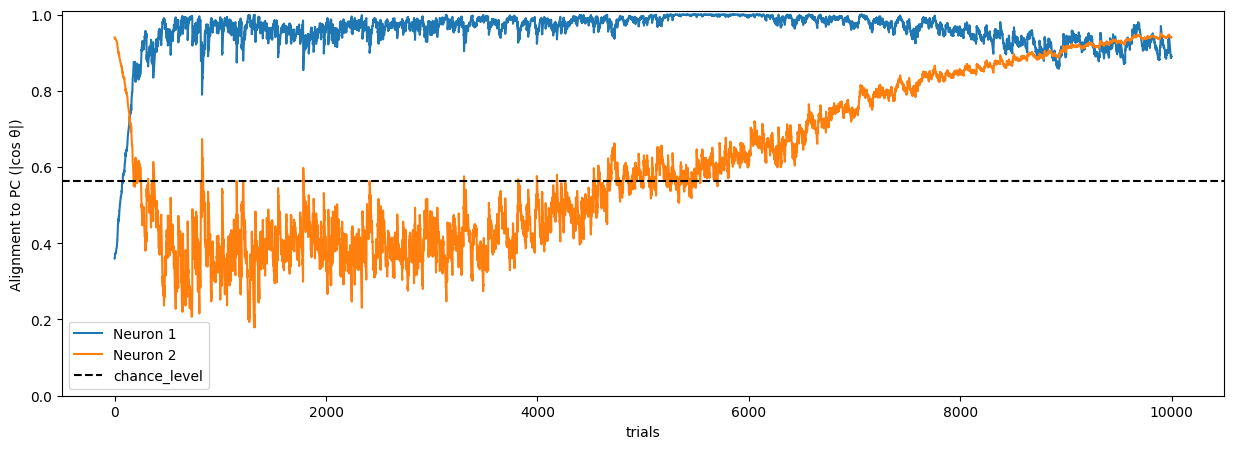

after second phase: model.W = [[ 0.42405356 -0.43047724]
 [-0.58413668 -0.58537529]]; model.V = [[ 0.         -0.52333054]
 [-0.52333054  0.        ]]
run 10 | order = [1 0] | best|corr|= [0.889 0.94 ]


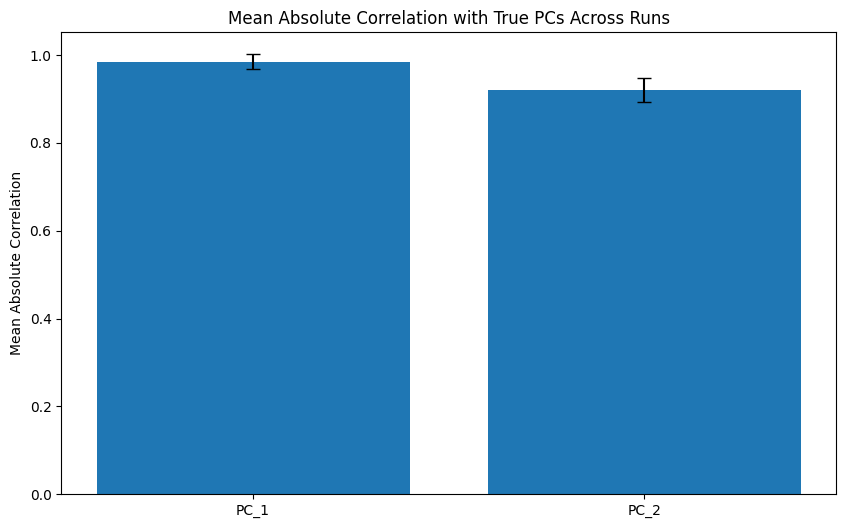

In [8]:
### Two phase training and testing

def two_phase_training_testing(model, data_before, data_after, m, model_paras_after, runs =10, graph = True):
    df_best_corr = pd.DataFrame(data=np.full((runs, m), np.nan), 
                            columns=[f"PC_{i+1}" for i in range(m)],
                            index=[f"run_{i+1}" for i in range(runs)])
    for run in range(runs):
        print(f"run {run+1:2d}")
        print(f"X_before")
        order, similarity = Y_aligned_training_testing_online(model, data_before, graph=True)
        print(f"After first phase: model.W = {model.W}, model.V: {model.V}")

        print(f"X_after")
        # update the model parameters
        for key, value in model_paras_after.items():
            if hasattr(model, key):
                setattr(model, key, value)

        order, similarity = Y_aligned_training_testing_online(model, data_after, graph=True)
        print(f"after second phase: model.W = {model.W}; model.V = {model.V}")

        # based on the order, sort the similarity to match PC order
        combined_lists = zip(order, similarity)
        # Sort the pairs based on PC_orders
        sorted_combined_lists = sorted(combined_lists)
        # Unzip the sorted pairs
        _, ordered_similarity = zip(*sorted_combined_lists)
        df_best_corr.iloc[run, :] = ordered_similarity
        print(f"run {run+1:2d} | order = {order} | best|corr|= {np.round(similarity,3)}")
        leen_model.reset()

    if graph == True:
        # plot the bar graph with error bars of mean and std based on df_best_corr
        means = df_best_corr.mean(axis=0)
        stds = df_best_corr.std(axis=0)
        plt.figure(figsize=(10, 6))
        plt.bar(means.index, means.values, yerr=stds.values, capsize=5)
        # plt.ylim(0, 1.1)
        plt.ylabel('Mean Absolute Correlation')
        plt.title('Mean Absolute Correlation with True PCs Across Runs')
        plt.show()
    

leen_model  = LeenCompletePCA(**model_paras)

two_phase_training_testing(leen_model, X_before, X_after, m, model_paras, runs = 10, graph = True)
